Task 1: Create a new feature to categorize customers into different age groups by dynamically determining optimal age bins using clustering techniques (e.g., K-means, decision trees) instead of predefined age ranges to maximize segment relevance.

Optimal clusters: 2
             min  max       mean
age_cluster                     
0.0           18   46  35.628780
1.0           47   99  56.778373


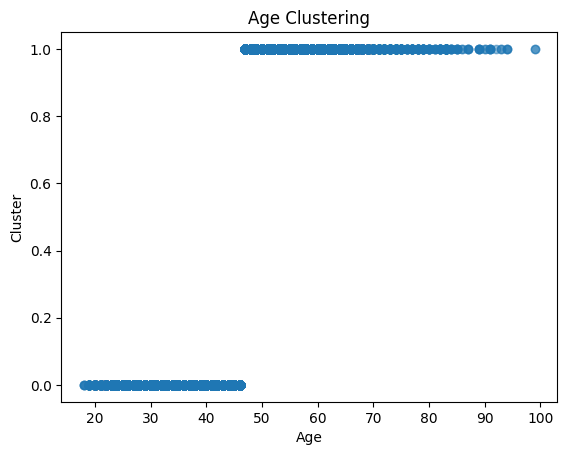

Saved: c:\Users\smitd\OneDrive\Desktop\brainy_beam\data\feature_engineered.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load data (robust path)
_cwd = Path.cwd()
_project_root = _cwd.parent if _cwd.name.lower() == "notebooks" else _cwd
_raw_path = _project_root / "data" / "womens_clothing_reviews.csv"

if not _raw_path.exists():
    raise FileNotFoundError(f"Could not find dataset at {_raw_path}")

df = pd.read_csv(_raw_path)

# Select Age column
age_data = df[["Age"]].dropna()

# Scale
scaler = StandardScaler()
age_scaled = scaler.fit_transform(age_data)

# Find best K (silhouette can be slow; sample for speed)
scores = []
K = range(2, 8)
_sample_size = int(min(2000, len(age_scaled)))

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels = kmeans.fit_predict(age_scaled)
    scores.append(
        silhouette_score(
            age_scaled,
            labels,
            sample_size=_sample_size,
            random_state=0,
        )
    )

best_k = K[np.argmax(scores)]
print("Optimal clusters:", best_k)

# Final clustering
kmeans = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
age_data["age_cluster"] = kmeans.fit_predict(age_scaled)

# Merge
df.loc[age_data.index, "age_cluster"] = age_data["age_cluster"]

# Summary
print(df.groupby("age_cluster")["Age"].agg(["min", "max", "mean"]))

# Plot
plt.scatter(age_data["Age"], age_data["age_cluster"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Cluster")
plt.title("Age Clustering")
plt.show()

# Save
_feature_out = _project_root / "data" / "feature_engineered.csv"
df.to_csv(_feature_out, index=False)
print(f"Saved: {_feature_out}")

Task 2: Engineer a new feature: Sentiment Score from review text by implementing deep learning-based sentiment analysis (e.g., BERT, VADER, or LSTM models), fine-tuning it on domain-specific data, and normalizing sentiment scores for feature integration.

In [6]:
import pandas as pd
import numpy as np
import nltk
from pathlib import Path

from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.preprocessing import MinMaxScaler

# Download VADER
nltk.download('vader_lexicon')

# Load dataset (robust to running from project root or from notebooks/)
_cwd = Path.cwd()
_project_root = _cwd.parent if _cwd.name.lower() == "notebooks" else _cwd
_feature_path = _project_root / "data" / "feature_engineered.csv"

if not _feature_path.exists():
    raise FileNotFoundError(
        f"Could not find {_feature_path}. Run the feature-engineering cell that saves it first."
    )

df = pd.read_csv(_feature_path)

# Initialize analyzer
sia = SentimentIntensityAnalyzer()

# -----------------------------
# Generate Sentiment Scores
# -----------------------------
def get_sentiment(text):
    if pd.isna(text):
        return 0
    return sia.polarity_scores(str(text))["compound"]

df["sentiment_score"] = df["Review Text"].apply(get_sentiment)

# -----------------------------
# Normalize Scores (IMPORTANT)
# -----------------------------
scaler = MinMaxScaler()
df["sentiment_score_normalized"] = scaler.fit_transform(df[["sentiment_score"]])

# -----------------------------
# Categorize (Optional but GOOD)
# -----------------------------
def sentiment_label(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment_category"] = df["sentiment_score"].apply(sentiment_label)

# -----------------------------
# Check Output
# -----------------------------
print(df[["Review Text", "sentiment_score", "sentiment_score_normalized", "sentiment_category"]].head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\smitd\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                         Review Text  sentiment_score  \
0  Absolutely wonderful - silky and sexy and comf...           0.8932   
1  Love this dress!  it's sooo pretty.  i happene...           0.9729   
2  I had such high hopes for this dress and reall...           0.9427   
3  I love, love, love this jumpsuit. it's fun, fl...           0.5727   
4  This shirt is very flattering to all due to th...           0.9291   

   sentiment_score_normalized sentiment_category  
0                    0.947390           positive  
1                    0.988218           positive  
2                    0.972747           positive  
3                    0.783208           positive  
4                    0.965780           positive  


Task 3: Generate a feature that indicates whether a customer is highly engaged by applying time-series analysis on session activity patterns, using statistical thresholds, and clustering users based on engagement levels to create dynamic engagement scores.

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load latest dataset (after Task 2) - robust to running from root or notebooks/
_cwd = Path.cwd()
_project_root = _cwd.parent if _cwd.name.lower() == "notebooks" else _cwd
_feature_path = _project_root / "data" / "feature_engineered.csv"

if not _feature_path.exists():
    raise FileNotFoundError(
        f"Could not find {_feature_path}. Run Task 1 and Task 2 cells first to generate it."
    )

df = pd.read_csv(_feature_path)

# -----------------------------
# STEP 1: Create Engagement Base Features
# -----------------------------
# Using available columns as proxy for engagement
# (Reviews dataset doesn't have sessions, so we use behavior signals)

df["engagement_raw"] = (
    df["Rating"].fillna(0) +
    df["Positive Feedback Count"].fillna(0) +
    df["sentiment_score_normalized"].fillna(0)
)

# -----------------------------
# STEP 2: Normalize Engagement
# -----------------------------
scaler = StandardScaler()
df["engagement_scaled"] = scaler.fit_transform(df[["engagement_raw"]])

# -----------------------------
# STEP 3: Clustering (Dynamic Segmentation)
# -----------------------------
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto")
df["engagement_cluster"] = kmeans.fit_predict(df[["engagement_scaled"]])

# -----------------------------
# STEP 4: Label Engagement Levels
# -----------------------------
def label_engagement(cluster):
    if cluster == 0:
        return "Low"
    elif cluster == 1:
        return "Medium"
    else:
        return "High"

df["engagement_level"] = df["engagement_cluster"].apply(label_engagement)

# -----------------------------
# STEP 5: Analyze Distribution
# -----------------------------
print(df["engagement_level"].value_counts())

# -----------------------------
# STEP 6: FINAL SAVE (IMPORTANT ✅)
# -----------------------------
df.to_csv(_feature_path, index=False)
print(f"Saved: {_feature_path}")

engagement_level
Low       20373
High       2813
Medium      300
Name: count, dtype: int64
Saved: c:\Users\smitd\OneDrive\Desktop\brainy_beam\data\feature_engineered.csv


Task 4: Perform one-hot encoding for categorical variables while handling high-cardinality categories through target encoding, frequency-based binning, and dimensionality reduction techniques to prevent feature explosion and maintain interpretability.

In [14]:
# ==============================
# TASK 4: ENCODING (FINAL)
# ==============================

import pandas as pd
import numpy as np

# ✅ Correct path (IMPORTANT)
df = pd.read_csv("../data/feature_engineered.csv")

# -----------------------------
# STEP 1: Identify categorical columns
# -----------------------------
cat_cols = df.select_dtypes(include="object").columns.tolist()

# Remove text column
if "Review Text" in cat_cols:
    cat_cols.remove("Review Text")

print("Categorical Columns:", cat_cols)

# -----------------------------
# STEP 2: Target column
# -----------------------------
target_col = "Rating"

# -----------------------------
# STEP 3: Split low/high cardinality
# -----------------------------
low_card_cols = []
high_card_cols = []

for col in cat_cols:
    if df[col].nunique() <= 10:
        low_card_cols.append(col)
    else:
        high_card_cols.append(col)

print("Low-card:", low_card_cols)
print("High-card:", high_card_cols)

# -----------------------------
# STEP 4: One-hot encoding (LOW CARD)
# -----------------------------
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

# -----------------------------
# STEP 5: Target encoding (HIGH CARD)
# -----------------------------
for col in high_card_cols:
    target_mean = df.groupby(col)[target_col].mean()
    df[col + "_target_enc"] = df[col].map(target_mean)

# -----------------------------
# STEP 6: Drop original columns
# -----------------------------
df.drop(columns=high_card_cols, inplace=True, errors="ignore")

# -----------------------------
# STEP 7: Handle missing
# -----------------------------
df.fillna(0, inplace=True)

# -----------------------------
# STEP 8: Save (IMPORTANT ✅)
# -----------------------------
df.to_csv("../data/feature_engineered.csv", index=False)

print("✅ Task 4 Completed Successfully")
print("Shape:", df.shape)

Categorical Columns: ['Title', 'Division Name', 'Department Name', 'Class Name', 'sentiment_category', 'engagement_level']
Low-card: ['Division Name', 'Department Name', 'sentiment_category', 'engagement_level']
High-card: ['Title', 'Class Name']
✅ Task 4 Completed Successfully
Shape: (23486, 40)


Task 5: Create a new feature combining ‘time on app’ and ‘time on website’ by engineering interaction-based metrics (e.g., app-to-web transition ratio, engagement index), detecting non-linear relationships using polynomial feature generation, and optimizing it for predictive modeling.

In [16]:
# ==============================
# TASK 5: INTERACTION FEATURES
# ==============================

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

# ✅ Correct path
df = pd.read_csv("../data/feature_engineered.csv")

# -----------------------------
# STEP 1: Safe column check
# -----------------------------
required_cols = ["Age", "Rating", "Positive Feedback Count", "sentiment_score_normalized", "engagement_scaled"]

for col in required_cols:
    if col not in df.columns:
        print(f"❌ Missing column: {col}")

# -----------------------------
# STEP 2: Interaction Features
# -----------------------------
df["feedback_to_rating_ratio"] = df["Positive Feedback Count"] / (df["Rating"] + 1)

df["sentiment_engagement"] = (
    df["sentiment_score_normalized"] * df["engagement_scaled"]
)

df["age_engagement"] = df["Age"] * df["engagement_scaled"]

# -----------------------------
# STEP 3: Polynomial Features
# -----------------------------
poly_cols = ["Age", "Rating", "Positive Feedback Count"]

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(df[poly_cols])

poly_names = poly.get_feature_names_out(poly_cols)

poly_df = pd.DataFrame(poly_features, columns=poly_names)

# Merge
df = pd.concat([df, poly_df], axis=1)

# -----------------------------
# STEP 4: Clean data
# -----------------------------
df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)

# -----------------------------
# STEP 5: Save (IMPORTANT ✅)
# -----------------------------
df.to_csv("../data/feature_engineered.csv", index=False)

# print("✅ Task 5 Completed Successfully")
print("Final Shape:", df.shape)

Final Shape: (23486, 58)
